# 04. Customer Clustering (K-Means)

Áp dụng thuật toán học không giám sát K-Means để phân cụm khách hàng dựa trên hành vi chi tiêu và tần suất giao dịch.


In [1]:
# Setup environment and imports
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src import config


## 1. Chuẩn Bị Dữ Liệu & Chuẩn Hóa Scaling


In [2]:
from src.clustering import prepare_clustering_features
from src.data_loader import load_processed_data

rfm_df = load_processed_data('rfm_clustering_features.csv')
X_scaled, scaler = prepare_clustering_features(rfm_df)

print(f"Kich thuoc du lieu chuan hoa: {X_scaled.shape}")

Kich thuoc du lieu chuan hoa: (4334, 3)


## 2. Xác Định K Tối Ưu (Elbow Method & Silhouette)


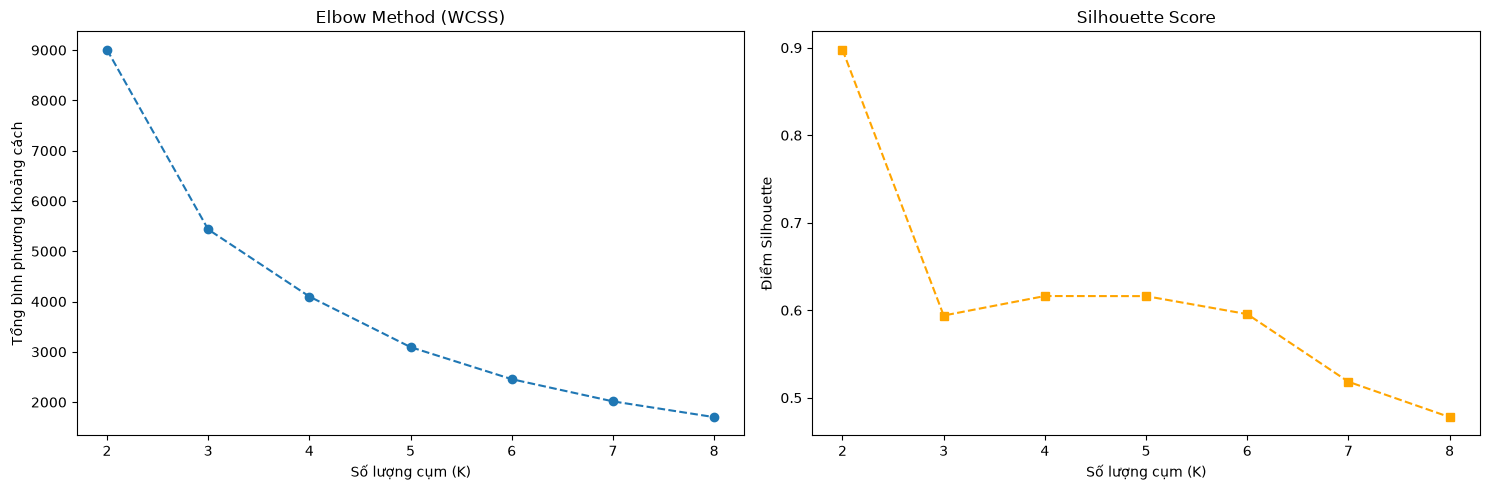

In [3]:
from src.clustering import find_optimal_k
metrics = find_optimal_k(X_scaled, max_k=8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(metrics['k_values'], metrics['wcss'], marker='o', linestyle='--')
ax1.set_title('Elbow Method (WCSS)')
ax1.set_xlabel('Số lượng cụm (K)')
ax1.set_ylabel('Tổng bình phương khoảng cách')

ax2.plot(metrics['k_values'], metrics['silhouette_scores'], marker='s', color='orange', linestyle='--')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Số lượng cụm (K)')
ax2.set_ylabel('Điểm Silhouette')

plt.tight_layout()
plt.show()

## 3. Huấn Luyện K-Means & Gán Nhãn Cụm


In [4]:
from src.clustering import train_kmeans
kmeans, clusters = train_kmeans(
    X_scaled, 
    n_clusters=4, 
    scaler=scaler, 
    model_save_path='../models/clustering/kmeans_model.pkl'
)
rfm_df['Cluster'] = clusters
print("Đã huấn luyện và lưu mô hình thành công!")

Đã huấn luyện và lưu mô hình thành công!


## 4. Diễn Giải Đặc Tính Các Cụm Khách Hàng


d:\HK1 2026-2027\KTDL\Data-mining\notebooks\..\src\visualization.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Recency', data=df, ax=axes[0], palette=palette)
d:\HK1 2026-2027\KTDL\Data-mining\notebooks\..\src\visualization.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Frequency', data=df, ax=axes[1], palette=palette)
d:\HK1 2026-2027\KTDL\Data-mining\notebooks\..\src\visualization.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Monetary', data=df, ax=axes[2], palette=palette

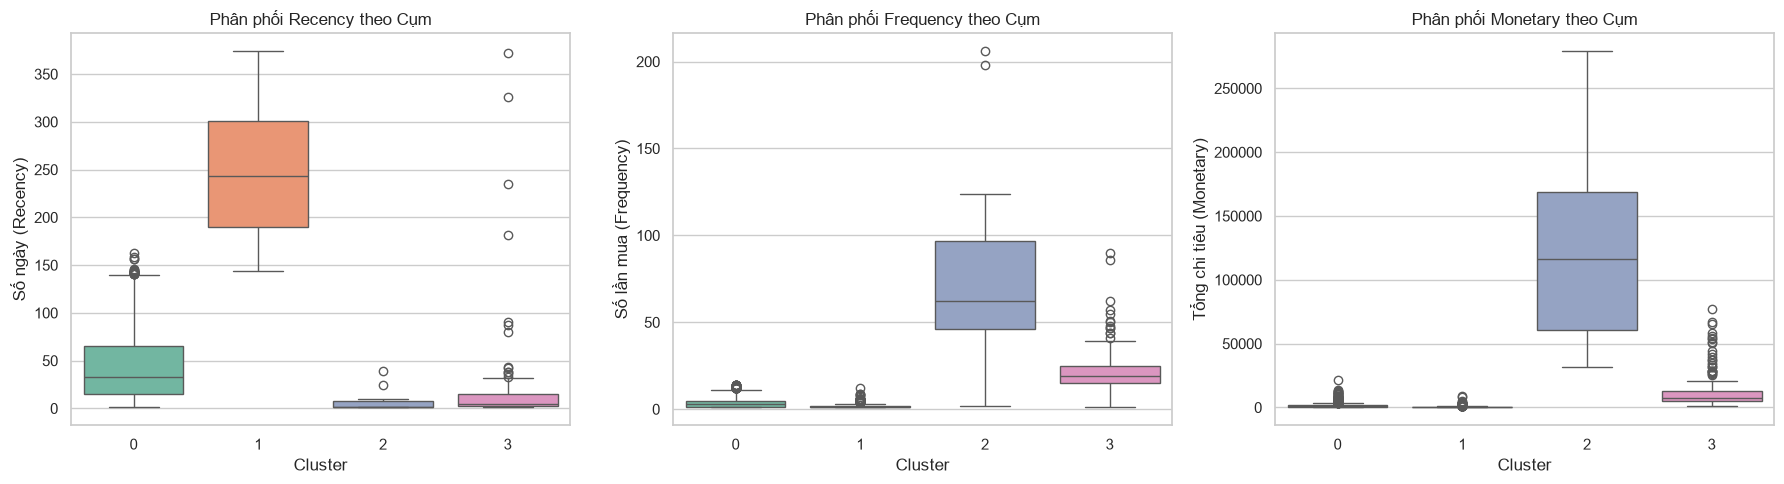

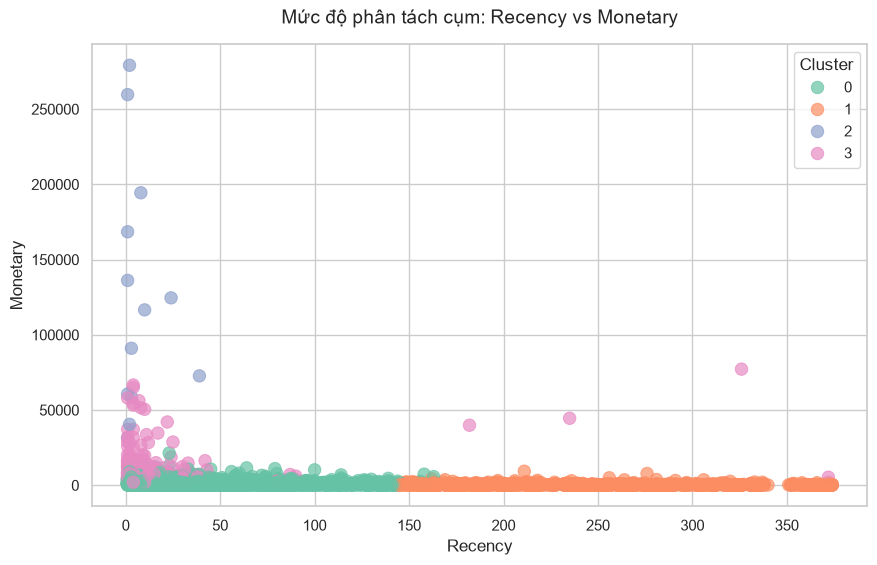


--- BẢNG TỔNG KẾT ĐẶC TÍNH CÁC CỤM KHÁCH HÀNG ---


,Recency,Frequency,Monetary,Customer_Count,Customer_Percent (%)
Cluster,,,,,
0,43.84,3.64,1322.51,3045,70.26
1,248.54,1.54,474.12,1066,24.60
2,7.38,81.77,125712.09,13,0.30
3,15.40,21.97,12240.55,210,4.85


,Recency,Frequency,Monetary
Cluster,,,
0,43.84,3.64,1322.51
1,248.54,1.54,474.12
2,7.38,81.77,125712.09
3,15.40,21.97,12240.55


In [5]:
from src.visualization import plot_clusters
from IPython.display import display

# 1. Vẽ và lưu các biểu đồ phân tích cụm vào thư mục outputs
plot_clusters(rfm_df, output_dir='../outputs/figures/clustering')

# 2. Tạo bảng thống kê trung bình (Centroids) của từng cụm
cluster_summary = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

# 3. Thêm cột thống kê quy mô (số lượng khách hàng) trong từng cụm
cluster_summary['Customer_Count'] = rfm_df.groupby('Cluster')['CustomerID'].count()
cluster_summary['Customer_Percent (%)'] = (cluster_summary['Customer_Count'] / len(rfm_df) * 100).round(2)

# 4. Hiển thị bảng tổng kết
print("\n--- BẢNG TỔNG KẾT ĐẶC TÍNH CÁC CỤM KHÁCH HÀNG ---")
display(cluster_summary)

# Hiển thị bảng thống kê trung bình
display(rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2))